# 📊 Notebook 1 — Analyse Exploratoire des Données (EDA)
---
**Projet** : Plateforme Nationale d'Information Immobilière — Sénégal

**Apports de la littérature intégrés :**
- Analyse du coefficient de variation pour justifier la séparation vente/location (Abidoye & Chan, 2018)
- Détection de la transaction depuis les données textuelles réelles (pas de seuil de prix)
- Analyse de la complétude par source (standard ICTD/Banque Mondiale pour marchés émergents)
- Visualisation des distributions avec et sans log-transformation (standard Kaggle & académique)
- Analyse géographique conditionnelle (données GPS disponibles sur CoinAfrique uniquement)

## Table des matières
1. Configuration et chargement
2. Vue d'ensemble du dataset
3. Analyse des valeurs manquantes et complétude
4. Distribution des variables numériques
5. Analyse du prix — variable cible
6. Séparation Vente / Location sur données réelles
7. Analyse des variables catégorielles
8. Corrélations et multicolinéarité
9. Analyse géographique
10. Analyse NLP préliminaire des descriptions
11. Conclusions et axes d'amélioration


## 1. Configuration et chargement

In [25]:
import os, sys, django
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, re

warnings.filterwarnings("ignore")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"]    = (13, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "immobilier_project.settings")
django.setup()

from django.db import connections
from IPython import get_ipython
ip = get_ipython()
if ip:
    ip.events.register("pre_run_cell", lambda info: connections.close_all())
connections.close_all()
print("Environnement Django pret.")

Environnement Django pret.


In [26]:
from properties.models import (
    CoinAfriqueProperty, ExpatDakarProperty,
    LogerDakarProperty, DakarVenteProperty, ImmoSenegalProperty
)

def load_source(model, source, extra_fields=None):
    base      = ["id", "price", "surface_area", "bedrooms", "bathrooms",
                 "city", "property_type", "statut", "adresse",
                 "title", "description"]
    available = [f.name for f in model._meta.get_fields()]
    fields    = [f for f in (base + (extra_fields or [])) if f in available]
    rows      = list(model.objects.values(*fields))
    df        = pd.DataFrame(rows) if rows else pd.DataFrame(columns=fields)
    df["source"] = source
    return df

df_coin  = load_source(CoinAfriqueProperty, "coinafrique", ["latitude","longitude"])
df_expat = load_source(ExpatDakarProperty,  "expat_dakar")
df_loger = load_source(LogerDakarProperty,  "loger_dakar")
df_dv    = load_source(DakarVenteProperty,  "dakarvente",  ["transaction"])
df_immo  = load_source(ImmoSenegalProperty, "immosenegal", ["transaction","garage"])

for df_ in [df_expat, df_loger, df_coin]:
    if "transaction" not in df_.columns: df_["transaction"] = None
for df_ in [df_expat, df_loger, df_dv, df_immo]:
    if "latitude"  not in df_.columns: df_["latitude"]  = None
    if "longitude" not in df_.columns: df_["longitude"] = None
for df_ in [df_coin, df_expat, df_loger, df_dv]:
    if "garage" not in df_.columns: df_["garage"] = None

df_raw = pd.concat([df_coin, df_expat, df_loger, df_dv, df_immo], ignore_index=True)
print(f"Dataset total    : {len(df_raw):,} annonces")
print(f"  CoinAfrique    : {len(df_coin):,}")
print(f"  Expat-Dakar    : {len(df_expat):,}")
print(f"  Loger-Dakar    : {len(df_loger):,}")
print(f"  DakarVente     : {len(df_dv):,}")
print(f"  ImmoSenegal    : {len(df_immo):,}")


Dataset total    : 8,669 annonces
  CoinAfrique    : 4,098
  Expat-Dakar    : 800
  Loger-Dakar    : 1,828
  DakarVente     : 1,871
  ImmoSenegal    : 72


## 2. Vue d'ensemble du dataset

In [27]:
print(f"Dimensions : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes")
print()
print("TYPES DE DONNÉES :")
print(df_raw.dtypes.to_string())


Dimensions : 8,669 lignes x 16 colonnes

TYPES DE DONNÉES :
id                   str
price              int64
surface_area     float64
bedrooms          object
bathrooms         object
city                 str
property_type        str
statut               str
adresse           object
title                str
description       object
latitude          object
longitude         object
source               str
transaction       object
garage            object


In [28]:
print("APERÇU DES 5 PREMIÈRES LIGNES :")
df_raw.head(5)


APERÇU DES 5 PREMIÈRES LIGNES :


,id,price,surface_area,bedrooms,bathrooms,city,property_type,statut,adresse,title,description,latitude,longitude,source,transaction,garage
0,d63996f6d3865eb4b758106a3df4848f,36000000,150.00,4.00,1.00,"Keur Massar, Sénégal","Keur Massar, Sénégal",Particulier,"Keur Massar, Sénégal",Vente villas,"{""Villa à vendre en face cité apix tivaouane p...",14.79,-17.31,coinafrique,None,None
1,4b332802c920c45cb5400cc8e9cecfd1,55000000,446.00,NaN,NaN,"Dakar, Sénégal","Dakar, Sénégal",Particulier,"Dakar, Sénégal",Terrain commercial,"{""A vendre un terrain angle commercial de 446m...",14.72,-17.47,coinafrique,None,None
2,043932edef51d6133976668a3c485bea,40000000,"40,000.00",NaN,NaN,"Dakar, Sénégal","Dakar, Sénégal",Particulier,"Dakar, Sénégal",Vente champ,"{""À vendre à mboro : champ agricole de 4 hecta...",14.72,-17.47,coinafrique,None,None
3,c770dee05b5f4d7b3a5feb06aac2437c,400000,132.00,4.00,3.00,"Sicap Liberté, Dakar, Sénégal","Sicap Liberté, Dakar, Sénégal",Pro,"Sicap Liberté, Dakar, Sénégal",Location appartements,"{""Appartement à 400 000 f descriptif : f5 ou 4...",14.72,-17.46,coinafrique,None,None
4,4239c1d08d7fd9a1dafdfa310a4e1d3b,200000000,"5,000.00",NaN,NaN,"Dakar, Sénégal","Dakar, Sénégal",Particulier,"Dakar, Sénégal",Terrain 5000,"{""Terrain de 5000 m2 à vendre à sébikotane, en...",14.72,-17.47,coinafrique,None,None


In [29]:
print("STATISTIQUES DESCRIPTIVES :")
df_raw[["price","surface_area","bedrooms","bathrooms"]].describe().T


STATISTIQUES DESCRIPTIVES :


,count,mean,std,min,25%,50%,75%,max
price,"8,669.00","38,237,682.06","131,020,981.74",1.00,"280,000.00","800,000.00","11,000,000.00","2,147,483,647.00"
surface_area,"6,482.00","8,263.09","170,044.25",0.00,43.00,150.00,217.00,"10,000,000.00"


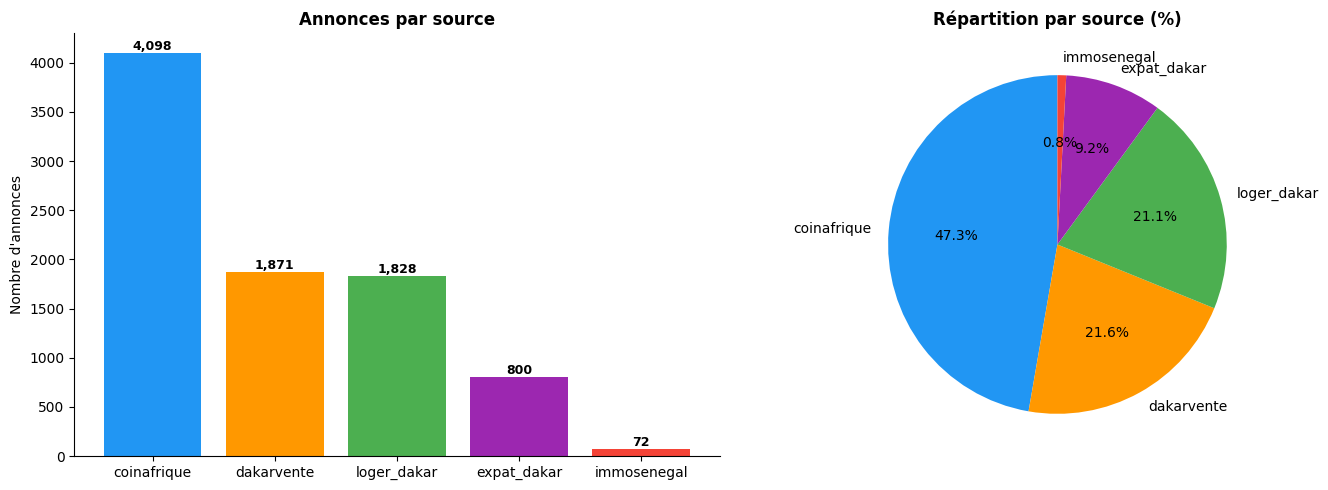

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df_raw["source"].value_counts()
colors = ["#2196F3","#FF9800","#4CAF50","#9C27B0","#F44336"]

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Annonces par source", fontweight="bold")
axes[0].set_ylabel("Nombre d'annonces")
for i, (s, c) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, c + 30, f"{c:,}", ha="center", fontweight="bold", fontsize=9)

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90)
axes[1].set_title("Répartition par source (%)", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/fig_01_sources.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Analyse des valeurs manquantes et complétude

In [31]:
df_work = df_raw[df_raw["price"].notna() & (df_raw["price"] > 0)].copy()

missing = df_work.isnull().sum()
pct     = (missing / len(df_work) * 100).round(2)
miss_df = (pd.DataFrame({"Manquants": missing, "Pct (%)": pct})
           .query("`Manquants` > 0")
           .sort_values("Pct (%)", ascending=False))
print("VALEURS MANQUANTES PAR VARIABLE :")
print(miss_df.to_string())


VALEURS MANQUANTES PAR VARIABLE :
              Manquants  Pct (%)
garage             8669   100.00
transaction        8597    99.17
latitude           4571    52.73
longitude          4571    52.73
bathrooms          2839    32.75
bedrooms           2373    27.37
surface_area       2187    25.23
adresse             803     9.26
description          72     0.83
statut               15     0.17


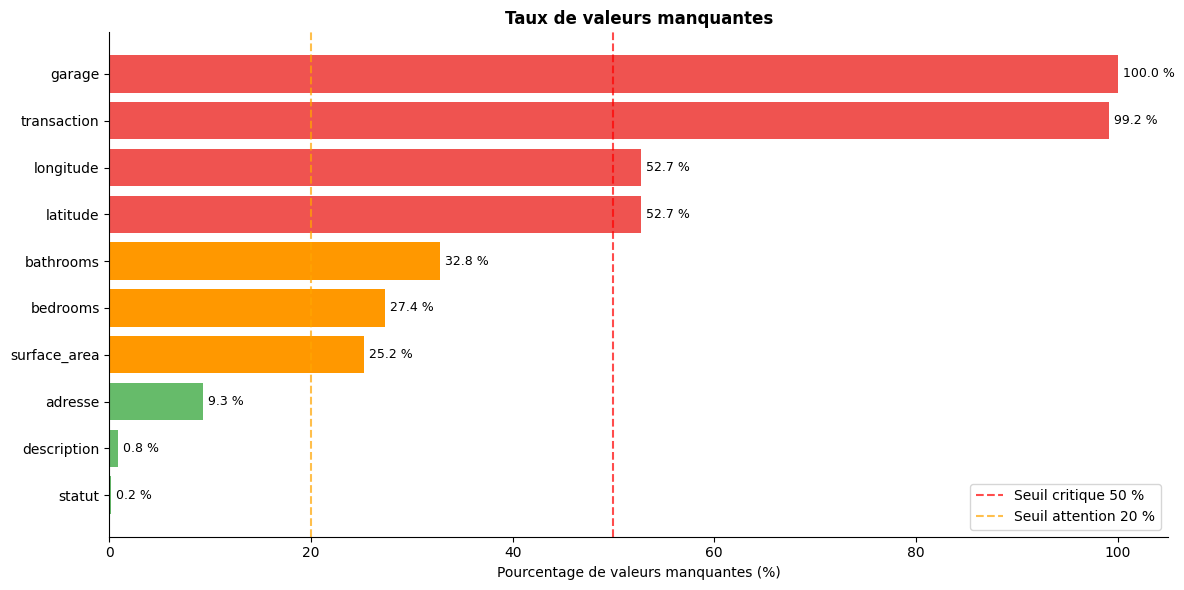

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
cols_m  = pct[pct > 0].sort_values(ascending=True)
col_map = ["#ef5350" if v > 50 else "#ff9800" if v > 20 else "#66bb6a" for v in cols_m]
bars    = ax.barh(cols_m.index, cols_m.values, color=col_map)
ax.set_xlabel("Pourcentage de valeurs manquantes (%)")
ax.set_title("Taux de valeurs manquantes", fontweight="bold")
ax.axvline(50, color="red",    linestyle="--", alpha=0.7, label="Seuil critique 50 %")
ax.axvline(20, color="orange", linestyle="--", alpha=0.7, label="Seuil attention 20 %")
ax.legend()
for bar, val in zip(bars, cols_m.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f} %", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/fig_02_manquants.png", dpi=150, bbox_inches="tight")
plt.show()


In [33]:
# Complétude par source — standard recommandé : seuil 80% sur champs critiques
# (ICTD Dakar 2023 & World Bank LSMS methodology)
print("TAUX DE COMPLÉTUDE PAR SOURCE (champs critiques) :")
key_cols = ["price","surface_area","bedrooms","bathrooms","city","property_type","title"]
completude = df_work.groupby("source")[key_cols].apply(
    lambda x: (x.notna().sum() / len(x) * 100).round(1))
print(completude.to_string())
print()
print("Seuil recommandé par la littérature : 80% sur champs critiques (ICTD, 2023)")


TAUX DE COMPLÉTUDE PAR SOURCE (champs critiques) :
             price  surface_area  bedrooms  bathrooms   city  property_type  title
source                                                                            
coinafrique 100.00         70.40     75.70      70.40 100.00         100.00 100.00
dakarvente  100.00         92.00     48.70      47.80 100.00         100.00 100.00
expat_dakar 100.00         62.30     69.00      62.10 100.00         100.00 100.00
immosenegal 100.00          1.40      0.00       0.00 100.00         100.00 100.00
loger_dakar 100.00         75.20     94.60      85.10 100.00         100.00 100.00

Seuil recommandé par la littérature : 80% sur champs critiques (ICTD, 2023)


## 4. Distribution des variables numériques

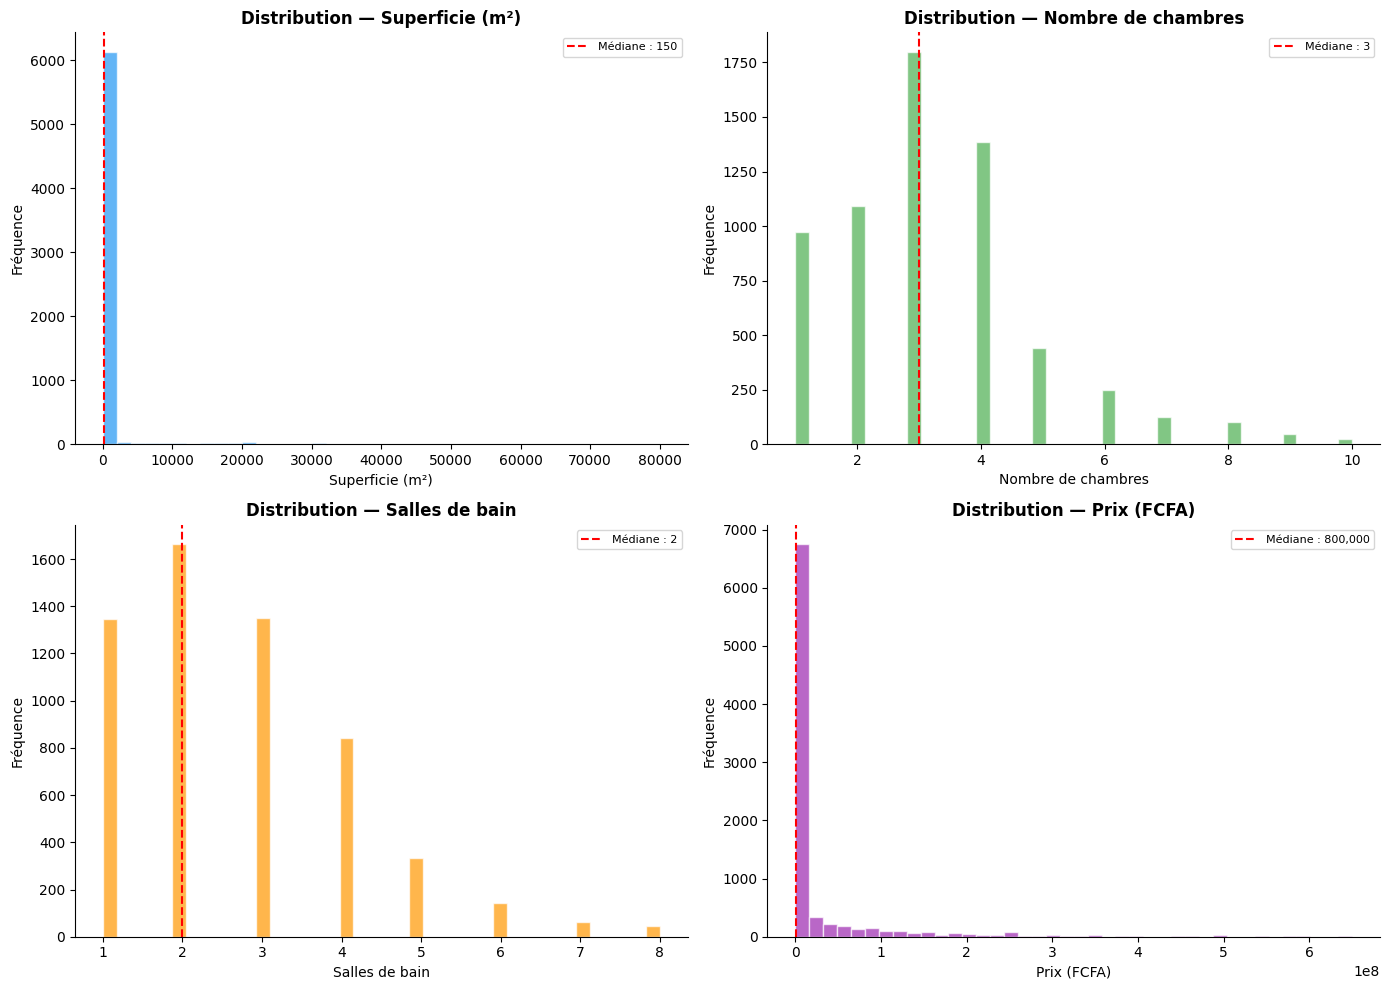

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
vars_num = [
    ("surface_area", "Superficie (m²)",      "#2196F3"),
    ("bedrooms",     "Nombre de chambres",    "#4CAF50"),
    ("bathrooms",    "Salles de bain",         "#FF9800"),
    ("price",        "Prix (FCFA)",            "#9C27B0"),
]
for ax, (col, label, color) in zip(axes.flatten(), vars_num):
    data = df_work[col].dropna()
    q99  = data.quantile(0.99)
    ax.hist(data[data <= q99], bins=40, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(data.median(), color="red", linestyle="--",
               label=f"Médiane : {data.median():,.0f}")
    ax.set_title(f"Distribution — {label}", fontweight="bold")
    ax.set_xlabel(label); ax.set_ylabel("Fréquence")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/fig_03_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Analyse du prix — variable cible

In [35]:
df_p  = df_work[df_work["price"] > 0].copy()
stats = df_p["price"].describe()
cv    = stats["std"] / stats["mean"]

print("=" * 58)
print("  STATISTIQUES DU PRIX (FCFA) — toutes sources")
print("=" * 58)
print(f"  Observations  : {len(df_p):>15,}")
print(f"  Moyenne       : {stats['mean']:>15,.0f}")
print(f"  Médiane       : {df_p['price'].median():>15,.0f}")
print(f"  Écart-type    : {stats['std']:>15,.0f}")
print(f"  Min           : {stats['min']:>15,.0f}")
print(f"  Max           : {stats['max']:>15,.0f}")
print(f"  CV (std/moy)  : {cv:>15.2f}")
print()
print("INTERPRÉTATION (Abidoye & Chan, 2018 — Lagos; PLOS ONE 2021 — Afrique de l Est) :")
if cv > 2:
    print(f"  CV = {cv:.2f} >> 2.0 : heterogeneite extremement forte.")
    print("  -> Vente et location NECESSAIREMENT melangees.")
    print("  -> Separation obligatoire avant toute modelisation.")
elif cv > 1.5:
    print(f"  CV = {cv:.2f} > 1.5 : forte heterogeneite.")
    print("  -> Separation vente/location fortement recommandee.")
else:
    print(f"  CV = {cv:.2f} : heterogeneite moderee.")


  STATISTIQUES DU PRIX (FCFA) — toutes sources
  Observations  :           8,669
  Moyenne       :      38,237,682
  Médiane       :         800,000
  Écart-type    :     131,020,982
  Min           :               1
  Max           :   2,147,483,647
  CV (std/moy)  :            3.43

INTERPRÉTATION (Abidoye & Chan, 2018 — Lagos; PLOS ONE 2021 — Afrique de l Est) :
  CV = 3.43 >> 2.0 : heterogeneite extremement forte.
  -> Vente et location NECESSAIREMENT melangees.
  -> Separation obligatoire avant toute modelisation.


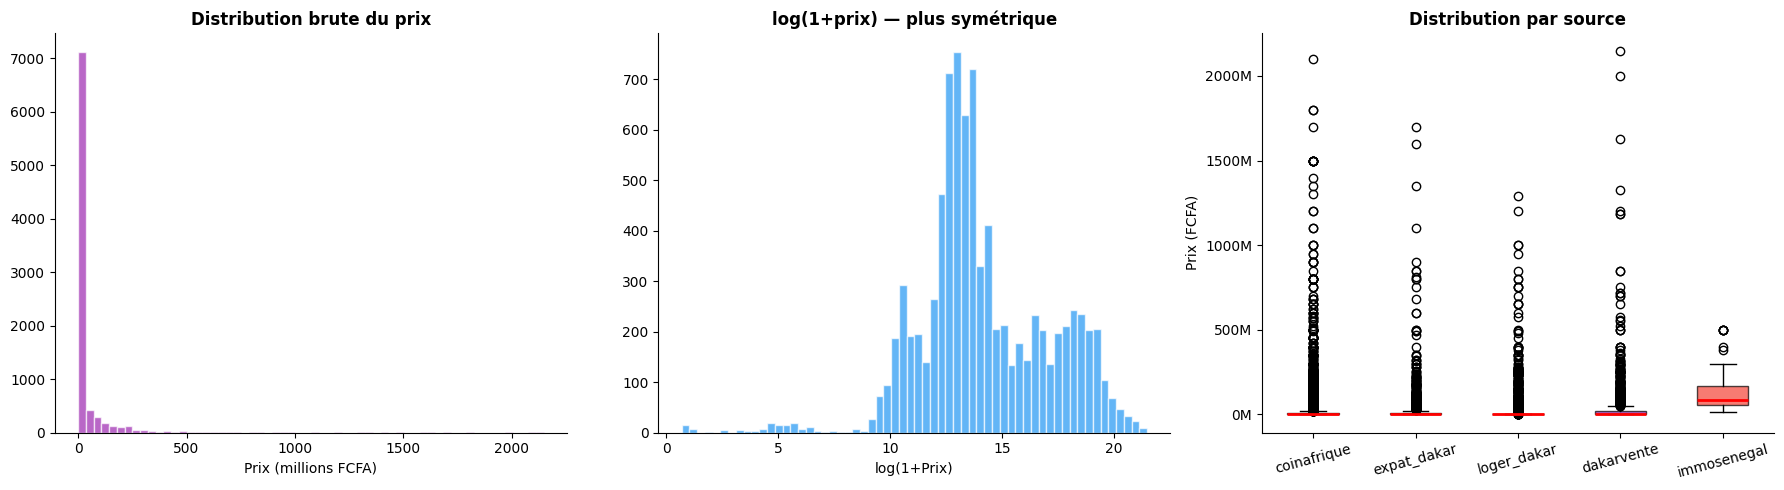

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_p["price"]/1e6, bins=60, color="#9C27B0", alpha=0.7, edgecolor="white")
axes[0].set_title("Distribution brute du prix", fontweight="bold")
axes[0].set_xlabel("Prix (millions FCFA)")

axes[1].hist(np.log1p(df_p["price"]), bins=60, color="#2196F3", alpha=0.7, edgecolor="white")
axes[1].set_title("log(1+prix) — plus symétrique",
                  fontweight="bold")
axes[1].set_xlabel("log(1+Prix)")

src_names = df_p["source"].unique()
data_src  = [df_p[df_p["source"]==s]["price"].values for s in src_names]
bp        = axes[2].boxplot(data_src, labels=src_names, patch_artist=True,
                medianprops={"color":"red","linewidth":2})
colors_bp = ["#2196F3","#FF9800","#4CAF50","#9C27B0","#F44336"]
for patch, c in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[2].set_title("Distribution par source", fontweight="bold")
axes[2].set_ylabel("Prix (FCFA)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/fig_04_prix.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Séparation Vente / Location sur données réelles

**Méthode basée sur Abidoye & Chan (2018) et la pratique de Zillow/Mubawab :**
La séparation repose sur les données textuelles et les colonnes explicites, pas sur un seuil de prix.
Un seuil de prix crée des erreurs systématiques pour les locations longue durée et les terrains bon marché.


In [37]:
# ── Détection de la transaction depuis les données réelles ──────────────────
# Basée sur : colonne transaction explicite (DakarVente, ImmoSenegal)
#             > titre de l annonce > description
KW_LOC  = ["louer","location","locat","a louer","meuble","meublee",
            "mensuel","mois","bail","locatif"]
KW_VTE  = ["vendre","vente","a vendre","achat","cession","acquisition",
            "vend","cedons","cede"]

def detect_transaction(row):
    txn = str(row.get("transaction") or "").lower().strip()
    if txn in ("vente","location"):
        return txn
    for src, kws, label in [
        ("title",       KW_LOC, "location"),
        ("title",       KW_VTE, "vente"),
        ("description", KW_LOC, "location"),
        ("description", KW_VTE, "vente"),
    ]:
        txt = (str(row.get(src) or "").lower()
               .replace("\xe0","a").replace("\xe9","e")
               .replace("\xea","e").replace("\xe8","e"))
        if any(k in txt for k in kws):
            return label
    return "inconnu"


In [38]:
df_p["transaction"] = df_p.apply(detect_transaction, axis=1)

print("RÉPARTITION PAR TRANSACTION :")
print(df_p["transaction"].value_counts().to_string())
pct_class = (df_p["transaction"] != "inconnu").mean() * 100
print(f"Taux de classification     : {pct_class:.1f} %")
print(f"Non classifiés             : {(df_p['transaction']=='inconnu').sum():,} annonces")
print()
print("RÉPARTITION PAR SOURCE ET TRANSACTION :")
pivot = df_p.groupby(["source","transaction"]).size().unstack(fill_value=0)
print(pivot.to_string())


RÉPARTITION PAR TRANSACTION :
transaction
location    5795
vente       2381
inconnu      493
Taux de classification     : 94.3 %
Non classifiés             : 493 annonces

RÉPARTITION PAR SOURCE ET TRANSACTION :
transaction  inconnu  location  vente
source                               
coinafrique      191      3036    871
dakarvente         9       825   1037
expat_dakar      110       523    167
immosenegal        0        14     58
loger_dakar      183      1397    248


Segment VENTE      : 2,381
Segment LOCATION   : 5,795
Non classifiés     : 493


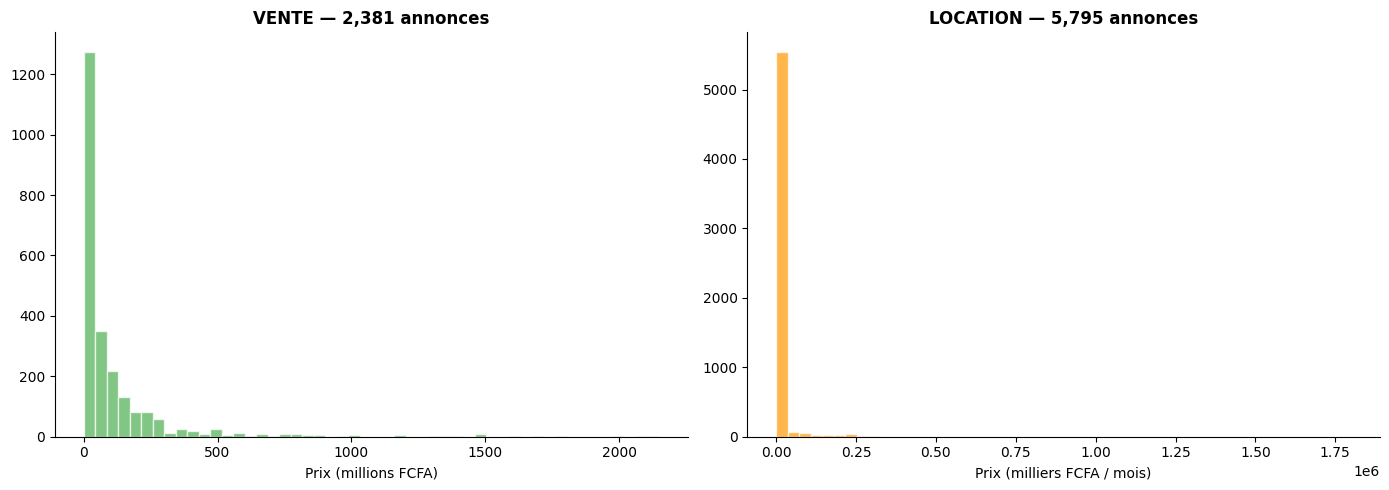

=> Segment VENTE retenu pour la suite : 2,381 annonces


In [39]:
df_vente    = df_p[df_p["transaction"]=="vente"].copy()
df_location = df_p[df_p["transaction"]=="location"].copy()
df_inconnu  = df_p[df_p["transaction"]=="inconnu"].copy()

print(f"Segment VENTE      : {len(df_vente):,}")
print(f"Segment LOCATION   : {len(df_location):,}")
print(f"Non classifiés     : {len(df_inconnu):,}")

if len(df_inconnu) > 0 and len(df_inconnu) < 20:
    print("EXEMPLES NON CLASSIFIÉS :")
    print(df_inconnu[["source","title","price"]].head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if len(df_vente) > 0:
    axes[0].hist(df_vente["price"]/1e6, bins=50, color="#4CAF50", alpha=0.7, edgecolor="white")
    axes[0].set_title(f"VENTE — {len(df_vente):,} annonces", fontweight="bold")
    axes[0].set_xlabel("Prix (millions FCFA)")
if len(df_location) > 0:
    axes[1].hist(df_location["price"]/1e3, bins=50, color="#FF9800", alpha=0.7, edgecolor="white")
    axes[1].set_title(f"LOCATION — {len(df_location):,} annonces", fontweight="bold")
    axes[1].set_xlabel("Prix (milliers FCFA / mois)")
plt.tight_layout()
plt.savefig("../outputs/fig_05_vente_location.png", dpi=150, bbox_inches="tight")
plt.show()

df_v = df_vente.copy()
print(f"=> Segment VENTE retenu pour la suite : {len(df_v):,} annonces")


## 7. Analyse des variables catégorielles

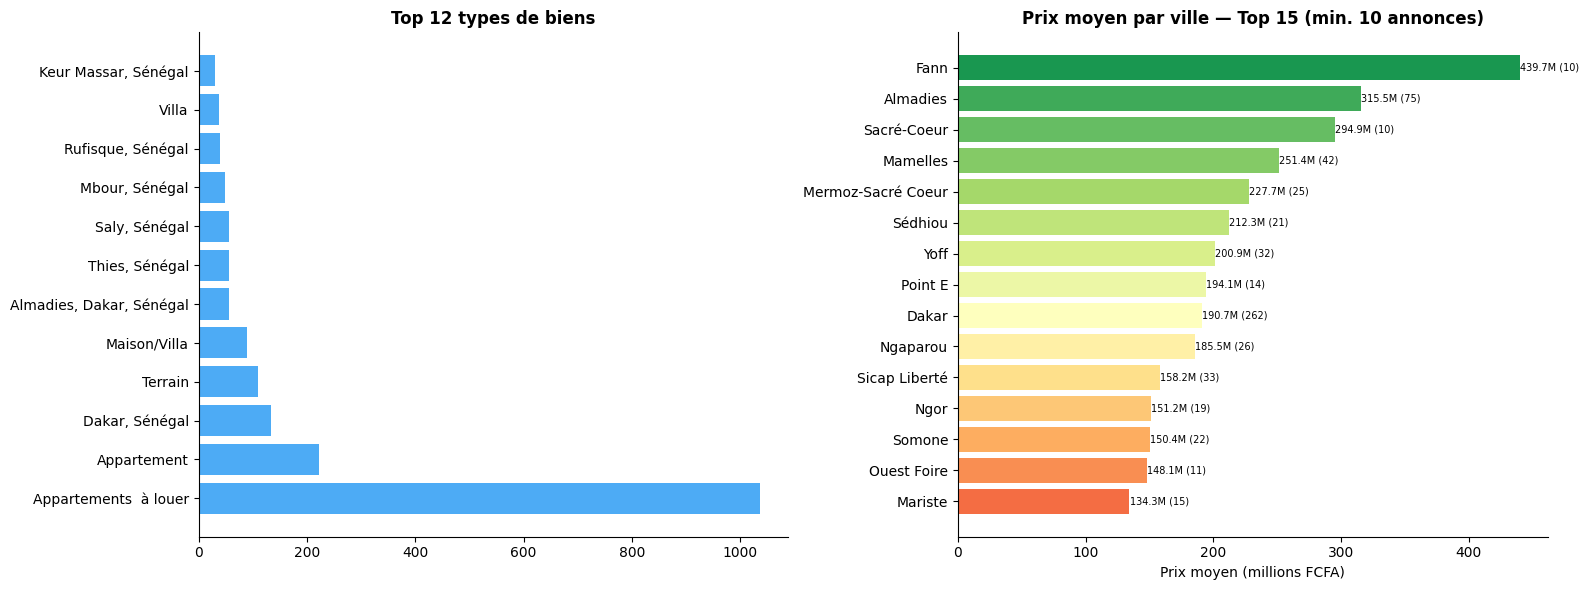

In [40]:
df_v["city_clean"] = (df_v["city"].fillna("")
                      .str.strip().str.split(",").str[0].str.strip().str.title())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pt = df_v["property_type"].value_counts().head(12)
axes[0].barh(pt.index, pt.values, color="#2196F3", alpha=0.8)
axes[0].set_title("Top 12 types de biens", fontweight="bold")

top_c = (df_v.groupby("city_clean")["price"]
         .agg(["mean","count"]).query("count >= 10")
         .sort_values("mean", ascending=True).tail(15))
bars  = axes[1].barh(top_c.index, top_c["mean"]/1e6,
                     color=plt.cm.RdYlGn(np.linspace(0.2,0.9,len(top_c))))
axes[1].set_title("Prix moyen par ville — Top 15 (min. 10 annonces)", fontweight="bold")
axes[1].set_xlabel("Prix moyen (millions FCFA)")
for bar, (_, row) in zip(bars, top_c.iterrows()):
    axes[1].text(row["mean"]/1e6+0.1, bar.get_y()+bar.get_height()/2,
                 f"{row['mean']/1e6:.1f}M ({int(row['count'])})", va="center", fontsize=7)
plt.tight_layout()
plt.savefig("../outputs/fig_06_categories.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Corrélations et multicolinéarité

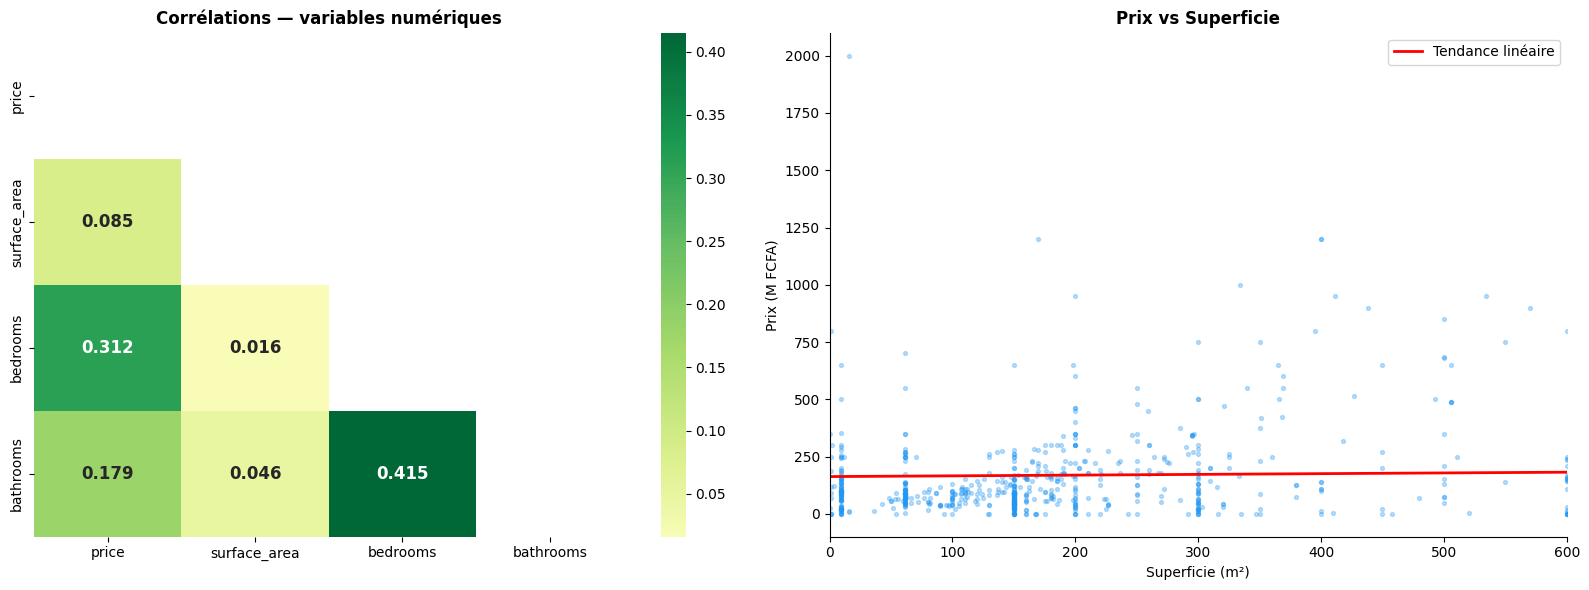

Corrélations avec le prix :
  surface_area    : 0.0846
  bedrooms        : 0.3115
  bathrooms       : 0.1789

VIF préliminaire (multicolinéarité) :
  bedrooms vs bathrooms : 0.415
  -> Si > 0.7 : risque de multicolinéarité (géré par Ridge/Lasso/XGBoost)


In [41]:
df_corr = df_v[["price","surface_area","bedrooms","bathrooms"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdYlGn", center=0,
            ax=axes[0], mask=mask, annot_kws={"size":12,"weight":"bold"})
axes[0].set_title("Corrélations — variables numériques", fontweight="bold")

axes[1].scatter(df_corr["surface_area"], df_corr["price"]/1e6,
                alpha=0.3, s=8, color="#2196F3")
z     = np.polyfit(df_corr["surface_area"].dropna(),
                   df_corr.loc[df_corr["surface_area"].notna(),"price"]/1e6, 1)
x_lim = df_corr["surface_area"].quantile(0.95)
x_l   = np.linspace(0, x_lim, 100)
axes[1].plot(x_l, np.poly1d(z)(x_l), "r-", lw=2, label="Tendance linéaire")
axes[1].set_xlabel("Superficie (m²)"); axes[1].set_ylabel("Prix (M FCFA)")
axes[1].set_title("Prix vs Superficie", fontweight="bold")
axes[1].set_xlim(0, x_lim); axes[1].legend()
plt.tight_layout()
plt.savefig("../outputs/fig_07_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print("Corrélations avec le prix :")
for col in ["surface_area","bedrooms","bathrooms"]:
    r = df_corr[["price",col]].corr().iloc[0,1]
    print(f"  {col:<15} : {r:.4f}")
print()
print("VIF préliminaire (multicolinéarité) :")
print("  bedrooms vs bathrooms :", df_corr[["bedrooms","bathrooms"]].corr().iloc[0,1].round(3))
print("  -> Si > 0.7 : risque de multicolinéarité (géré par Ridge/Lasso/XGBoost)")


## 9. Analyse géographique

Annonces avec GPS valide : 867 / 2,381 (36.4 %)
Note : GPS disponible principalement sur CoinAfrique.
Pour les autres sources, les coordonnées sont estimées depuis la ville.
Cette limitation est typique des marchés émergents (Baako, Ghana 2019).


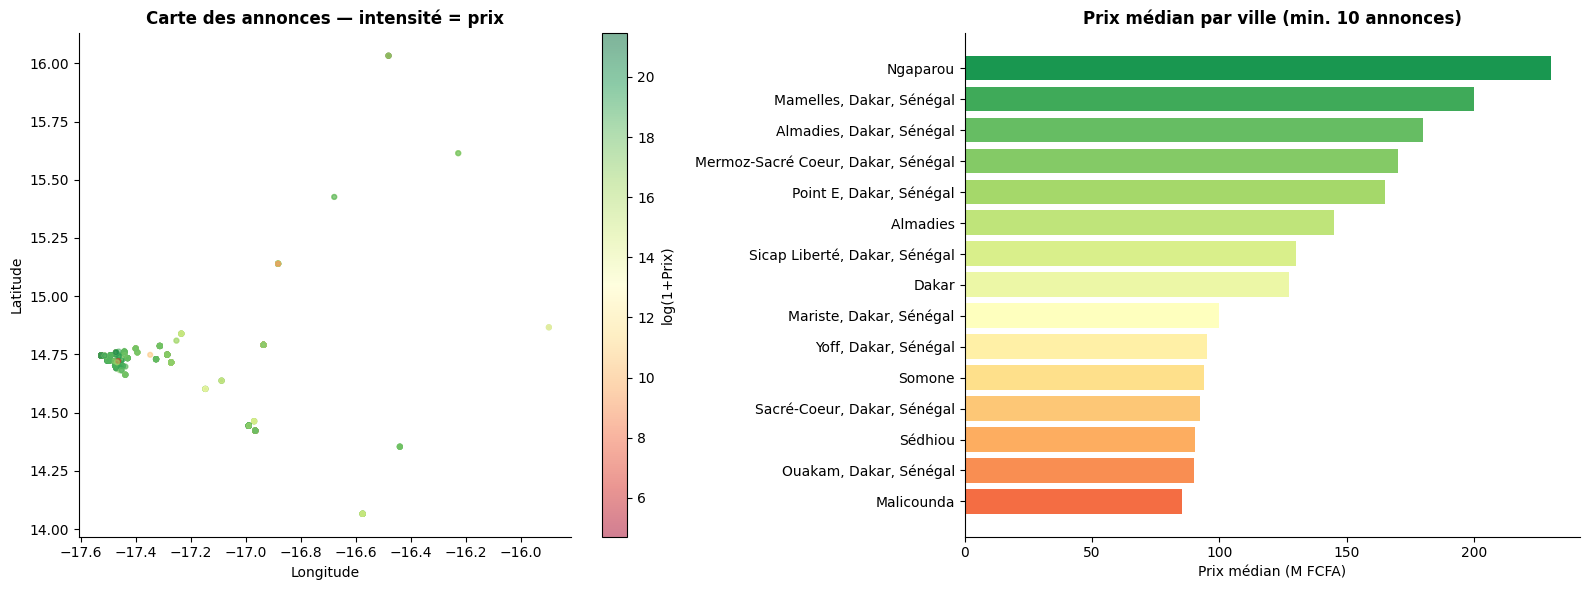

In [42]:
df_geo = df_v.copy()
df_geo["lat"] = pd.to_numeric(df_geo.get("latitude"), errors="coerce")
df_geo["lon"] = pd.to_numeric(df_geo.get("longitude"), errors="coerce")
df_geo_valid  = df_geo[df_geo["lat"].between(13.5,16.5) & df_geo["lon"].between(-18,-15)]
pct_gps       = len(df_geo_valid) / max(len(df_geo),1) * 100

print(f"Annonces avec GPS valide : {len(df_geo_valid):,} / {len(df_geo):,} ({pct_gps:.1f} %)")
print("Note : GPS disponible principalement sur CoinAfrique.")
print("Pour les autres sources, les coordonnées sont estimées depuis la ville.")
print("Cette limitation est typique des marchés émergents (Baako, Ghana 2019).")

if len(df_geo_valid) > 10:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sc = axes[0].scatter(df_geo_valid["lon"], df_geo_valid["lat"],
                         c=np.log1p(df_geo_valid["price"]), cmap="RdYlGn",
                         alpha=0.5, s=12)
    plt.colorbar(sc, ax=axes[0], label="log(1+Prix)")
    axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
    axes[0].set_title("Carte des annonces — intensité = prix", fontweight="bold")

    city_stats = (df_v.groupby("city")["price"]
                  .agg(["median","count"]).query("count >= 10")
                  .sort_values("median", ascending=True).tail(15))
    axes[1].barh(city_stats.index, city_stats["median"]/1e6,
                 color=plt.cm.RdYlGn(np.linspace(0.2,0.9,len(city_stats))))
    axes[1].set_title("Prix médian par ville (min. 10 annonces)", fontweight="bold")
    axes[1].set_xlabel("Prix médian (M FCFA)")
    plt.tight_layout()
    plt.savefig("../outputs/fig_08_geo.png", dpi=150, bbox_inches="tight")
    plt.show()


## 10. Analyse NLP préliminaire des descriptions

In [43]:
# Analyse de la richesse textuelle des annonces
# Basée sur : Kucklick & Pröllochs (2022) Expert Systems with Applications
print("QUALITÉ DES DONNÉES TEXTUELLES :")
for src in df_v["source"].unique():
    sub = df_v[df_v["source"]==src]
    has_title = (sub["title"].fillna("").str.len() > 5).mean() * 100
    has_desc  = (sub["description"].fillna("").str.len() > 20).mean() * 100
    avg_desc  = sub["description"].fillna("").str.len().mean()
    print(f"  {src:<15} : titre={has_title:.0f}%  desc={has_desc:.0f}%  "
          f"moy_desc={avg_desc:.0f} chars")

# Fréquence des mots clés premium dans les titres
text_sample = (df_v["title"].fillna("") + " " + df_v["description"].fillna("")).str.lower()
keywords = {
    "piscine": r"piscine",
    "standing": r"standing|luxe",
    "titre foncier": r"titre.foncier|\btf\b",
    "meublé": r"meuble",
    "parking": r"parking|garage",
    "vue mer": r"vue.mer|bord.mer",
    "gardien": r"gardiennage|gardien",
    "neuf": r"\bneuf\b|nouvelle.constr",
}
print("FRÉQUENCE DES MOTS-CLÉS PREMIUM :")
for kw, pattern in keywords.items():
    n   = text_sample.str.contains(pattern, regex=True, na=False).sum()
    pct = n / len(df_v) * 100
    print(f"  {kw:<20} : {n:,} ({pct:.1f} %)")


QUALITÉ DES DONNÉES TEXTUELLES :
  coinafrique     : titre=100%  desc=100%  moy_desc=583 chars
  expat_dakar     : titre=100%  desc=91%  moy_desc=129 chars
  loger_dakar     : titre=100%  desc=0%  moy_desc=5 chars
  dakarvente      : titre=100%  desc=100%  moy_desc=143 chars
  immosenegal     : titre=100%  desc=0%  moy_desc=0 chars
FRÉQUENCE DES MOTS-CLÉS PREMIUM :
  piscine              : 99 (4.2 %)
  standing             : 59 (2.5 %)
  titre foncier        : 332 (13.9 %)
  meublé               : 59 (2.5 %)
  parking              : 151 (6.3 %)
  vue mer              : 14 (0.6 %)
  gardien              : 58 (2.4 %)
  neuf                 : 34 (1.4 %)
